In [1]:
import xarray as xr
import geopandas as gpd
import rioxarray
import glob
import numpy as np

# --------------------------------------------
# Step 1: Load basin shapefile
# --------------------------------------------
basin_shp = "C:/Study area/Upper_Ravi_sub-basin/Upper_Ravi_sub-basin.shp"
basin = gpd.read_file(basin_shp)
basin = basin.to_crs("EPSG:4326")  # Ensure CRS matches raster

# --------------------------------------------
# Step 2: Load NetCDF files
# --------------------------------------------
imd_files = sorted(glob.glob("C:/Rainfall_NetCDF/*.nc"))    # IMD yearly NetCDFs
nex_files = sorted(glob.glob("C:/All GCM Data/KACE - 1-0-G/*.nc"))    # NEX yearly NetCDFs

imd = xr.open_mfdataset(imd_files, combine='by_coords')
nex = xr.open_mfdataset(nex_files, combine='by_coords')



In [2]:
# Step 3: Prepare variables
# --------------------------------------------
imd_var = imd['RAINFALL'].rename({"TIME":"time","LATITUDE":"lat","LONGITUDE":"lon"})
imd_var = imd_var.rio.write_crs("EPSG:4326")

nex_var = nex['pr'] * 86400  # Convert from m/s → mm/day
nex_var = nex_var.rename({"time":"time","lat":"lat","lon":"lon"})
nex_var = nex_var.rio.write_crs("EPSG:4326")


In [3]:
# Step 4: Get basin bounds + buffer
# --------------------------------------------
buffer_deg = 0.5  # Small buffer to ensure overlap (~2 NEX cells)
minx, miny, maxx, maxy = basin.total_bounds
subset_box = [minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg]


In [4]:
# Step 5: Subset NEX regionally (handle lat ordering)
# --------------------------------------------
# Latitude
if nex_var.lat.values[0] > nex_var.lat.values[-1]:
    lat_slice = slice(subset_box[3], subset_box[1])  # descending
else:
    lat_slice = slice(subset_box[1], subset_box[3])  # ascending

# Longitude (0-360° handled automatically)
nex_clip = nex_var.sel(
    lon=slice(subset_box[0], subset_box[2]),
    lat=lat_slice
)


In [5]:
# Step 6: Regrid NEX → IMD grid
# --------------------------------------------
nex_regridded = nex_clip.interp(
    lat=imd_var.lat,
    lon=imd_var.lon,
    method="linear"
)


In [6]:
# Step 7: Clip both datasets to basin
# --------------------------------------------
imd_clip = imd_var.rio.clip(list(basin.geometry), basin.crs, drop=True)
nex_clip = nex_regridded.rio.clip(list(basin.geometry), basin.crs, drop=True)


In [7]:
def check_spatial_grid(ds, name="Dataset"):
    print(f"--- {name} ---")
    print("Shape:", ds.shape)
    
    if 'lat' in ds.coords and 'lon' in ds.coords:
        print("Number of lat points:", len(ds.lat))
        print("Number of lon points:", len(ds.lon))
        print("Lat values:", ds.lat.values)
        print("Lon values:", ds.lon.values)
    else:
        print("No lat/lon coordinates found!")

    # Count valid (non-NaN) grid cells per time step
    import numpy as np
    valid_cells = np.isfinite(ds.values).sum(axis=(1,2))  # sum over lat/lon
    print("Number of valid grid cells per time step (first 5):", valid_cells[:5])
    print("\n")

# Check IMD
check_spatial_grid(imd_clip, name="IMD Clip")

# Check NEX
check_spatial_grid(nex_clip, name="NEX Clip")


--- IMD Clip ---
Shape: (10957, 3, 6)
Number of lat points: 3
Number of lon points: 6
Lat values: [32.25 32.5  32.75]
Lon values: [75.75 76.   76.25 76.5  76.75 77.  ]
Number of valid grid cells per time step (first 5): [9 9 9 9 9]


--- NEX Clip ---
Shape: (12600, 3, 6)
Number of lat points: 3
Number of lon points: 6
Lat values: [32.25 32.5  32.75]
Lon values: [75.75 76.   76.25 76.5  76.75 77.  ]
Number of valid grid cells per time step (first 5): [9 9 9 9 9]




## Export Daily Rainfall per Grid to CSV

In [ ]:
# =============================================
# Step 8: Convert each dataset to a DataFrame
# =============================================
# import pandas as pd

# def to_dataframe(ds, var_name="rainfall"):
#     """
#     Convert an xarray DataArray to a long-format pandas DataFrame.
#     """
#     df = ds.to_dataframe(name=var_name).reset_index()
    
#     # Remove NaNs (outside basin)
#     df = df.dropna(subset=[var_name])
#     return df

# # Convert IMD and NEX
# imd_df = to_dataframe(imd_clip, "IMD_rainfall_mmday")
# nex_df = to_dataframe(nex_clip, "NEX_rainfall_mmday")

# # =============================================
# # Step 9: Save to CSV
# # =============================================
# imd_csv = "C:/Rainfall_CSV/IMD_daily_grid_rainfall.csv"
# nex_csv = "C:/Rainfall_CSV/NEX_daily_grid_rainfall.csv"

# imd_df.to_csv(imd_csv, index=False)
# nex_df.to_csv(nex_csv, index=False)

# print("✅ CSV files saved successfully:")
# print(imd_csv)
# print(nex_csv)


In [8]:
print("Clipped dataset shape:", imd_clip.shape)
print("Latitude length:", len(imd_clip.lat))
print("Longitude length:", len(imd_clip.lon))


Clipped dataset shape: (10957, 3, 6)
Latitude length: 3
Longitude length: 6


In [9]:
print("Clipped dataset shape:", nex_clip.shape)
print("Latitude length:", len(nex_clip.lat))
print("Longitude length:", len(nex_clip.lon))


Clipped dataset shape: (12600, 3, 6)
Latitude length: 3
Longitude length: 6


In [9]:
print("IMD shape:", imd_clip.shape)
print("NEX shape:", nex_clip.shape)


IMD shape: (10957, 3, 6)
NEX shape: (10957, 3, 6)


In [11]:
print("IMD time coordinate:", imd_clip.time)
print("NEX time coordinate:", nex_clip.time)


IMD time coordinate: <xarray.DataArray 'time' (time: 10957)> Size: 88kB
array(['1985-01-01T00:00:00.000000000', '1985-01-02T00:00:00.000000000',
       '1985-01-03T00:00:00.000000000', ..., '2014-12-29T00:00:00.000000000',
       '2014-12-30T00:00:00.000000000', '2014-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 88kB 1985-01-01 1985-01-02 ... 2014-12-31
    spatial_ref  int64 8B 0
Attributes:
    axis:           T
    time_origin:    31-DEC-1900
    standard_name:  time
NEX time coordinate: <xarray.DataArray 'time' (time: 10957)> Size: 88kB
array(['1985-01-01T12:00:00.000000000', '1985-01-02T12:00:00.000000000',
       '1985-01-03T12:00:00.000000000', ..., '2014-12-29T12:00:00.000000000',
       '2014-12-30T12:00:00.000000000', '2014-12-31T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 88kB 1985-01-01T12:00:00 ... 2014-12-3...
    spatial_ref  int64 8B 0
Attributes:

## If lenght of days is not euqal

In [12]:
# Convert NEX time to pandas datetime (for noleap calendar)
import pandas as pd
nex_times = nex_clip['time'].values
nex_times_pd = pd.to_datetime([pd.Timestamp(t.strftime('%Y-%m-%d')) for t in nex_times])

# Assign back
nex_clip['time'] = nex_times_pd

In [10]:
import pandas as pd
import cftime
import pandas as pd


# ===========================================
# STEP A: Normalize time coordinates
# ===========================================

# Convert to pandas datetime (ensures same dtype)
imd_clip['time'] = pd.to_datetime(imd_clip['time'].values)
nex_clip['time'] = pd.to_datetime(nex_clip['time'].values)

# Floor both to daily timestamps (remove hours/minutes)
imd_clip['time'] = imd_clip['time'].dt.floor('D')
nex_clip['time'] = nex_clip['time'].dt.floor('D')

# ===========================================
# STEP B: Ensure both cover same daily range
# ===========================================
common_start = max(imd_clip.time.min(), nex_clip.time.min())
common_end   = min(imd_clip.time.max(), nex_clip.time.max())

imd_clip = imd_clip.sel(time=slice(common_start, common_end))
nex_clip = nex_clip.sel(time=slice(common_start, common_end))


In [11]:
# Show first and last 5 dates
print(imd_clip.time.isel(time=slice(0,5)).values)
print("...")
print(imd_clip.time.isel(time=slice(-5,None)).values)


['1985-01-01T00:00:00.000000000' '1985-01-02T00:00:00.000000000'
 '1985-01-03T00:00:00.000000000' '1985-01-04T00:00:00.000000000'
 '1985-01-05T00:00:00.000000000']
...
['2014-12-27T00:00:00.000000000' '2014-12-28T00:00:00.000000000'
 '2014-12-29T00:00:00.000000000' '2014-12-30T00:00:00.000000000'
 '2014-12-31T00:00:00.000000000']


In [12]:
# STEP C: Align them
# ===========================================
imd_clip, nex_clip = xr.align(imd_clip, nex_clip, join='inner')

# Verify alignment
print("✅ After normalization:")
print("IMD time range:", str(imd_clip.time.values[0]), "→", str(imd_clip.time.values[-1]))
print("NEX time range:", str(nex_regridded.time.values[0]), "→", str(nex_regridded.time.values[-1]))
print("Length IMD:", imd_clip.time.size, "| Length NEX:", nex_regridded.time.size)

✅ After normalization:
IMD time range: 1985-01-01T00:00:00.000000000 → 2014-12-31T00:00:00.000000000
NEX time range: 1985-01-01T12:00:00.000000000 → 2014-12-31T12:00:00.000000000
Length IMD: 10957 | Length NEX: 10957


In [12]:
print("IMD shape:", imd_clip.shape)
print("NEX shape:", nex_clip.shape)


IMD shape: (10957, 3, 6)
NEX shape: (10957, 3, 6)


In [16]:
def check_spatial_after_align(ds, name="Dataset"):
    print(f"--- {name} ---")
    print("Shape (time, lat, lon):", ds.shape)
    
    if 'lat' in ds.coords and 'lon' in ds.coords:
        print("Number of lat points:", len(ds.lat))
        print("Number of lon points:", len(ds.lon))
        print("Lat values:", ds.lat.values)
        print("Lon values:", ds.lon.values)
    else:
        print("No lat/lon coordinates found!")

# Check IMD after alignment
check_spatial_after_align(imd_clip, "IMD Clip (Aligned)")

# Check NEX after alignment
check_spatial_after_align(nex_clip, "NEX Clip (Aligned)")


--- IMD Clip (Aligned) ---
Shape (time, lat, lon): (10957, 3, 6)
Number of lat points: 3
Number of lon points: 6
Lat values: [32.25 32.5  32.75]
Lon values: [75.75 76.   76.25 76.5  76.75 77.  ]
--- NEX Clip (Aligned) ---
Shape (time, lat, lon): (10957, 3, 6)
Number of lat points: 3
Number of lon points: 6
Lat values: [32.25 32.5  32.75]
Lon values: [75.75 76.   76.25 76.5  76.75 77.  ]


In [13]:
# STEP 2: Define Quantile Mapping Function
# ===========================================
def quantile_mapping(obs, sim):
    """
    Empirical quantile mapping for 1D arrays.
    Returns array with same length as sim, keeping NaNs for invalid points.
    """
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs_valid, sim_valid = obs[mask], sim[mask]

    # Prepare full-length result
    result = np.full_like(sim, np.nan)

    # Only apply correction if enough valid points
    if len(obs_valid) >= 30:
        sim_sorted, sim_q = np.sort(sim_valid), np.linspace(0, 1, len(sim_valid))
        obs_sorted = np.sort(obs_valid)
        sim_ranks = stats.rankdata(sim_valid, method='average') / len(sim_valid)
        corrected = np.interp(sim_ranks, sim_q, obs_sorted)
        result[mask] = corrected  # only replace valid points

    # If <30 valid points, result stays NaN
    return result



In [14]:
# STEP 3: Apply Grid-to-Grid Bias Correction
# ===========================================
import numpy as np
from scipy import stats


corrected_values = np.empty_like(nex_clip.values)

for i in range(nex_clip.shape[1]):   # latitude index
    for j in range(nex_clip.shape[2]):  # longitude index
        obs_series = imd_clip[:, i, j].values
        sim_series = nex_clip[:, i, j].values
        corrected_values[:, i, j] = quantile_mapping(obs_series, sim_series)


C:\Users\Windows\anaconda3\Lib\site-packages\dask\array\reductions.py:655: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [16]:
# STEP 4: Store Corrected Data as xarray
# ===========================================
nex_corrected = xr.DataArray(
    data=corrected_values,
    dims=nex_clip.dims,
    coords=nex_clip.coords,
    name='pr_corrected',
    attrs=nex_clip.attrs
)

## Indices for IMD (Mean Annual, RX1day, RX3day)

In [22]:
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------
# 1. Make sure IMD data is ready and has CRS
# ------------------------------------------------
imd_clip = imd_clip.rio.write_crs("EPSG:4326")
time_imd = imd_clip['time']

# Define your flood months (same as EC-Earth3)
flood_months = [6, 7, 8, 9]   # JJAS monsoon; change if needed

# ===========================================
# 2. COMPUTE IMD RAINFALL INDICES
# ===========================================

# 2.1 Mean Annual Rainfall (IMD, mm/year)
# ---------------------------------------
annual_rain_imd = imd_clip.groupby(time_imd.dt.year).sum(dim='time')
mean_annual_imd = annual_rain_imd.mean(dim='year')
mean_annual_imd.name = "Mean_Annual_IMD"

# 2.2 RX1day (max 1-day rainfall in flood months, IMD)
# ----------------------------------------------------
flood_season_imd = imd_clip.where(time_imd.dt.month.isin(flood_months), drop=True)

rx1day_yearly_imd = flood_season_imd.groupby(flood_season_imd['time'].dt.year).max(dim='time')
rx1day_imd = rx1day_yearly_imd.mean(dim='year')
rx1day_imd.name = "RX1day_IMD"

# 2.3 RX3day (max 3-day total rainfall in flood months, IMD)
# ----------------------------------------------------------
flood_roll3_imd = flood_season_imd.rolling(time=3, min_periods=3).sum()
rx3day_yearly_imd = flood_roll3_imd.groupby(flood_roll3_imd['time'].dt.year).max(dim='time')
rx3day_imd = rx3day_yearly_imd.mean(dim='year')
rx3day_imd.name = "RX3day_IMD"

# Pack into a Dataset
indices_imd_ds = xr.Dataset({
    "Mean_Annual_IMD": mean_annual_imd,
    "RX1day_IMD": rx1day_imd,
    "RX3day_IMD": rx3day_imd
})

print("=== IMD Indices Dataset ===")
print(indices_imd_ds)
print()

# =====================================
# 3. QUICK STATS (text summary)
# =====================================
df_imd = indices_imd_ds.to_dataframe().reset_index()
print(df_imd.head())

for col in ["Mean_Annual_IMD", "RX1day_IMD", "RX3day_IMD"]:
    s = df_imd[col].dropna()
    print(f"\n--- {col} stats (mm) ---")
    print(s.describe())


=== IMD Indices Dataset ===
<xarray.Dataset> Size: 512B
Dimensions:          (lon: 6, lat: 3)
Coordinates:
  * lon              (lon) float64 48B 75.75 76.0 76.25 76.5 76.75 77.0
  * lat              (lat) float64 24B 32.25 32.5 32.75
    spatial_ref      int64 8B 0
Data variables:
    Mean_Annual_IMD  (lat, lon) float64 144B dask.array<chunksize=(3, 6), meta=np.ndarray>
    RX1day_IMD       (lat, lon) float64 144B dask.array<chunksize=(3, 6), meta=np.ndarray>
    RX3day_IMD       (lat, lon) float64 144B dask.array<chunksize=(3, 6), meta=np.ndarray>

     lon    lat  spatial_ref  Mean_Annual_IMD  RX1day_IMD  RX3day_IMD
0  75.75  32.25            0         0.000000         NaN         NaN
1  75.75  32.50            0         0.000000         NaN         NaN
2  75.75  32.75            0      1220.772129   69.115724  123.861862
3  76.00  32.25            0         0.000000         NaN         NaN
4  76.00  32.50            0         0.000000         NaN         NaN

--- Mean_Annual_IMD st

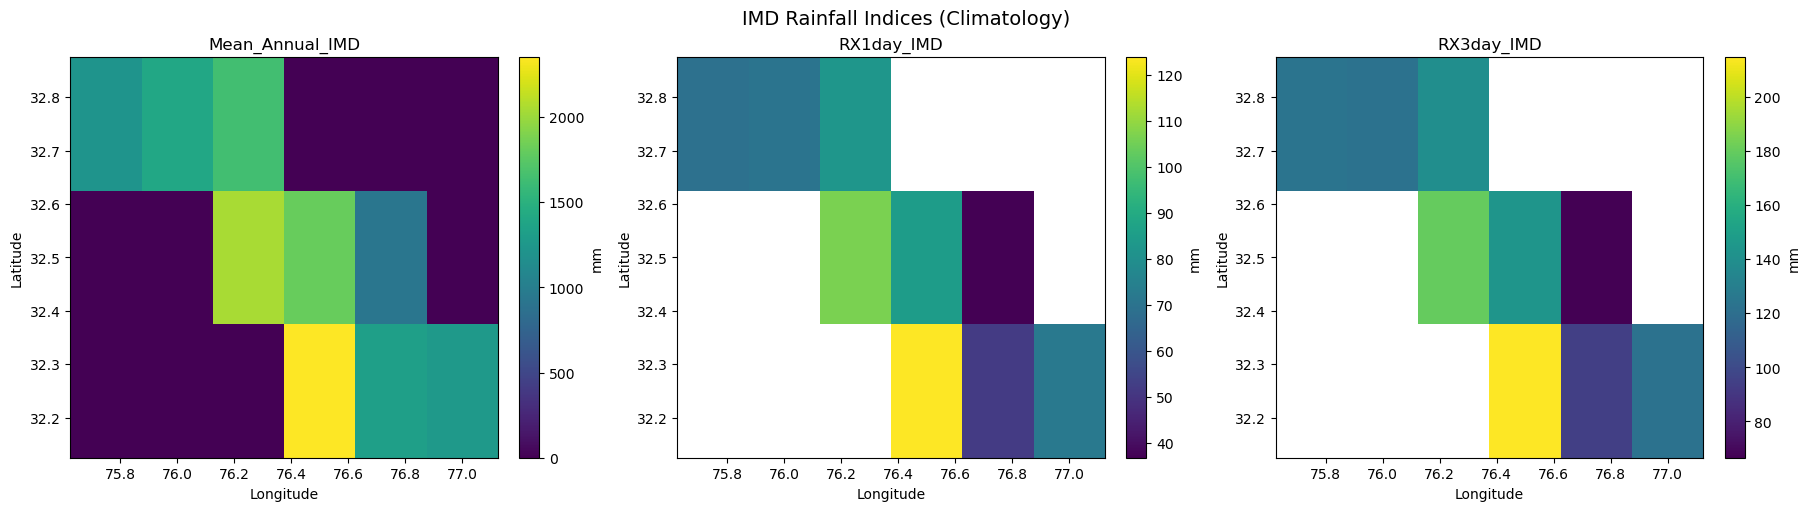

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, var in zip(
    axes,
    ["Mean_Annual_IMD", "RX1day_IMD", "RX3day_IMD"]
):
    da = indices_imd_ds[var]
    im = ax.pcolormesh(da['lon'], da['lat'], da, shading="auto")
    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mm")

plt.suptitle("IMD Rainfall Indices (Climatology)", fontsize=14)
plt.show()


In [24]:
out_dir_imd = "C:/Users/Windows/Desktop/Climate Figures/"

# ensure CRS for each DataArray
mean_annual_imd = mean_annual_imd.rio.write_crs("EPSG:4326")
rx1day_imd      = rx1day_imd.rio.write_crs("EPSG:4326")
rx3day_imd      = rx3day_imd.rio.write_crs("EPSG:4326")

mean_annual_imd.rio.to_raster(out_dir_imd + "Mean_Annual_IMD.tif")
rx1day_imd.rio.to_raster(out_dir_imd + "RX1day_IMD.tif")
rx3day_imd.rio.to_raster(out_dir_imd + "RX3day_IMD.tif")

print("✅ Saved IMD rasters to:", out_dir_imd)


✅ Saved IMD rasters to: C:/Users/Windows/Desktop/Climate Figures/


## Indices and plot

=== Indices Dataset ===
<xarray.Dataset> Size: 512B
Dimensions:      (lat: 3, lon: 6)
Coordinates:
  * lat          (lat) float64 24B 32.25 32.5 32.75
  * lon          (lon) float64 48B 75.75 76.0 76.25 76.5 76.75 77.0
    spatial_ref  int64 8B 0
Data variables:
    Mean_Annual  (lat, lon) float64 144B 0.0 0.0 0.0 2.295e+03 ... 0.0 0.0 0.0
    RX1day       (lat, lon) float64 144B nan nan nan 118.0 ... 84.88 nan nan nan
    RX3day       (lat, lon) float64 144B nan nan nan 222.6 ... 156.5 nan nan nan

--- Mean_Annual (mm) ---
count      18.000000
mean      760.261407
std       837.027241
min         0.000000
25%         0.000000
50%       453.651694
75%      1361.165818
max      2294.550979
Name: Mean_Annual, dtype: float64

--- RX1day (mm) ---
count      9.000000
mean      83.861170
std       19.785453
min       52.813690
25%       75.712013
50%       84.881983
75%       87.056577
max      118.005405
Name: RX1day, dtype: float64

--- RX3day (mm) ---
count      9.000000
mean     154.3308

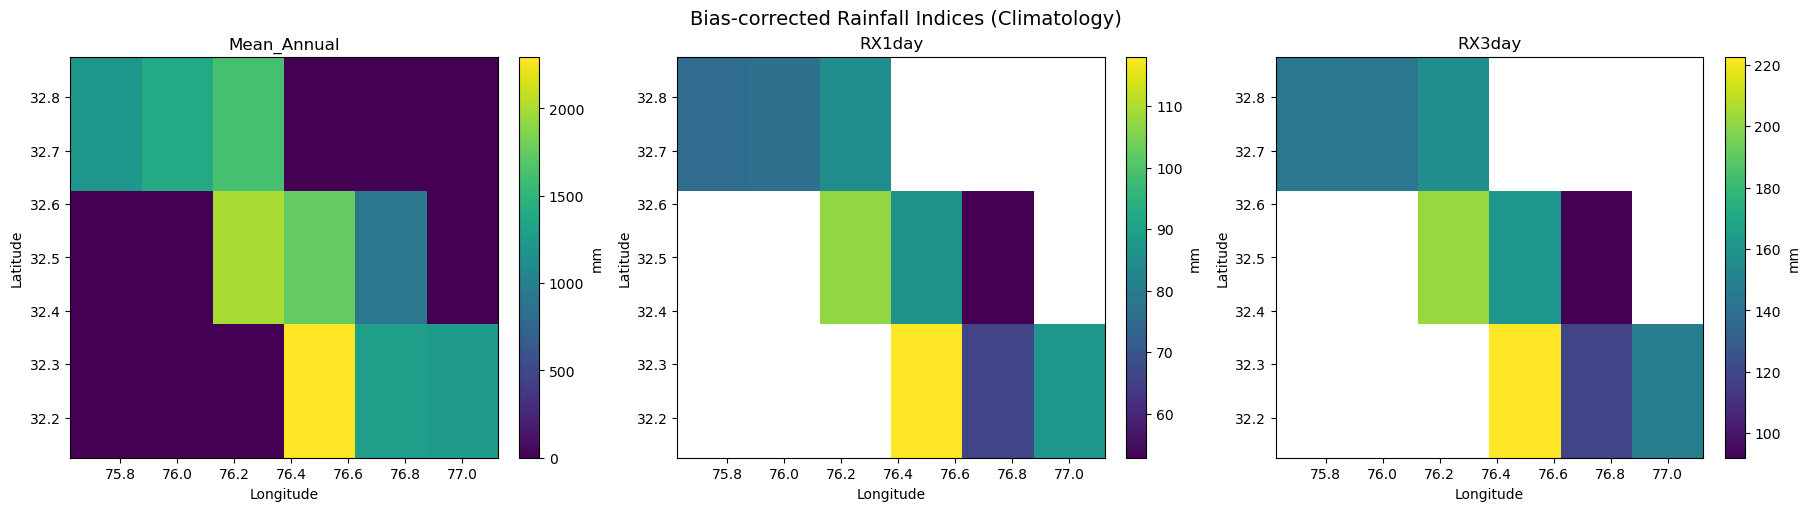

✅ Saved rasters to: C:/Users/Windows/Desktop/Climate Figures/
✅ Saved indices CSV to: C:/Users/Windows/Desktop/Climate Figures/rainfall_indices_points_corrected.csv
     lat    lon  spatial_ref  Mean_Annual      RX1day      RX3day
0  32.25  75.75            0     0.000000         NaN         NaN
1  32.25  76.00            0     0.000000         NaN         NaN
2  32.25  76.25            0     0.000000         NaN         NaN
3  32.25  76.50            0  2294.550979  118.005405  222.559952
4  32.25  76.75            0  1277.114683   65.862186  118.369020


In [21]:
# ==============================
# CONTINUE FROM YOUR SCRIPT HERE
# (after nex_corrected is created)
# ==============================

import rioxarray
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure CRS
# -------------
nex_corrected = nex_corrected.rio.write_crs("EPSG:4326")
time = nex_corrected['time']

# Define flood months (change if needed)
flood_months = [6, 7, 8, 9]   # JJAS monsoon

# ===========================================
# 2. COMPUTE INDICES (ON BIAS-CORRECTED DATA)
# ===========================================

# 2.1 Mean Annual Rainfall (mm/year)
# ----------------------------------
annual_rain = nex_corrected.groupby(time.dt.year).sum(dim='time')   # sum over days → annual total
mean_annual = annual_rain.mean(dim='year')                          # mean over all years
mean_annual.name = 'Mean_Annual'

# 2.2 RX1day (max 1-day rainfall in flood months)
# -----------------------------------------------
flood_season = nex_corrected.where(time.dt.month.isin(flood_months), drop=True)

rx1day_yearly = flood_season.groupby(flood_season['time'].dt.year).max(dim='time')
rx1day = rx1day_yearly.mean(dim='year')
rx1day.name = 'RX1day'

# 2.3 RX3day (max 3-day accumulated rainfall in flood months)
# -----------------------------------------------------------
flood_roll3 = flood_season.rolling(time=3, min_periods=3).sum()
rx3day_yearly = flood_roll3.groupby(flood_roll3['time'].dt.year).max(dim='time')
rx3day = rx3day_yearly.mean(dim='year')
rx3day.name = 'RX3day'

# Pack into one Dataset for convenience
indices_ds = xr.Dataset({
    'Mean_Annual': mean_annual,
    'RX1day': rx1day,
    'RX3day': rx3day
})

print("=== Indices Dataset ===")
print(indices_ds)
print()

# ============================
# 3. BASIC STATS (SHOW IN TEXT)
# ============================
for var in ['Mean_Annual', 'RX1day', 'RX3day']:
    da = indices_ds[var]
    series = da.to_series().dropna()
    print(f"--- {var} (mm) ---")
    print(series.describe())      # count, mean, std, min, quartiles, max
    print()

# ====================================
# 4. QUICK MAPS OF ALL INDICES (PLOTS)
# ====================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, var in zip(axes, ['Mean_Annual', 'RX1day', 'RX3day']):
    da = indices_ds[var]
    im = ax.pcolormesh(da['lon'], da['lat'], da, shading='auto')
    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mm")

plt.suptitle("Bias-corrected Rainfall Indices (Climatology)", fontsize=14)
plt.show()

# =========================================
# 5. CLIP TO BASIN & EXPORT AS RASTERS (TIF)
# =========================================
out_dir = "C:/Users/Windows/Desktop/Climate Figures/"  # change if needed

mean_annual_clip = mean_annual.rio.clip(basin.geometry, basin.crs, drop=True)
rx1day_clip      = rx1day.rio.clip(basin.geometry, basin.crs, drop=True)
rx3day_clip      = rx3day.rio.clip(basin.geometry, basin.crs, drop=True)

mean_annual_clip.rio.to_raster(out_dir + "Mean_Annual_corrected.tif")
rx1day_clip.rio.to_raster(out_dir + "RX1day_floodmonths_corrected.tif")
rx3day_clip.rio.to_raster(out_dir + "RX3day_floodmonths_corrected.tif")

print("✅ Saved rasters to:", out_dir)

# ========================================
# 6. ALSO SAVE POINT-WISE CSV OF INDICES
# ========================================
df_indices = indices_ds.to_dataframe().reset_index()
csv_path = out_dir + "rainfall_indices_points_corrected.csv"
df_indices.to_csv(csv_path, index=False)
print("✅ Saved indices CSV to:", csv_path)
print(df_indices.head())


In [20]:
# Convert 3D grid (time, lat, lon) to a DataFrame with columns:
# time | lat | lon | pr_corrected

df = nex_corrected.to_dataframe(name='pr_corrected').reset_index()

print(df.head())
print(df.shape)


        time    lat    lon  spatial_ref  pr_corrected
0 1985-01-01  32.25  75.75            0           NaN
1 1985-01-01  32.25  76.00            0           NaN
2 1985-01-01  32.25  76.25            0           NaN
3 1985-01-01  32.25  76.50            0           0.0
4 1985-01-01  32.25  76.75            0           0.0
(197226, 5)


In [21]:
df.to_csv("C:/Climate data/All Models QM csv/EC-eARTH3_daily_grid.csv", index=False)


## Export Gridwise Daily Corrected Data to CSV

In [ ]:
# # ===========================================
# # STEP 5: Export Corrected Daily Grid Data to CSV
# # ===========================================
# import pandas as pd

# def to_dataframe(ds, var_name="rainfall_corrected"):
#     """
#     Convert an xarray DataArray to a long-format pandas DataFrame.
#     
#     df = ds.to_dataframe(name=var_name).reset_index()
#     df = df.dropna(subset=[var_name])  # Drop NaNs (outside basin)
#     return df

# # Convert all three (if needed)
# imd_df = imd_clip.to_dataframe(name="IMD_rainfall_mmday").reset_index().dropna(subset=["IMD_rainfall_mmday"])
# nex_df = nex_clip.to_dataframe(name="NEX_rainfall_mmday").reset_index().dropna(subset=["NEX_rainfall_mmday"])
# nex_corr_df = to_dataframe(nex_corrected, "NEX_corrected_mmday")

# # Save to CSV
# imd_df.to_csv("C:/Rainfall_CSV/IMD_daily_grid.csv", index=False)
# nex_df.to_csv("C:/Rainfall_CSV/NEX_daily_grid.csv", index=False)
# nex_corr_df.to_csv("C:/Rainfall_CSV/NEX_corrected_daily_grid.csv", index=False)

# print("✅ CSVs saved successfully:")
# print("IMD:", "C:/Rainfall_CSV/IMD_daily_grid.csv")
# print("NEX:", "C:/Rainfall_CSV/NEX_daily_grid.csv")
# print("NEX Corrected:", "C:/Rainfall_CSV/NEX_corrected_daily_grid.csv")


In [16]:
import numpy as np

def compute_statistics(obs, sim):
    """
    Compute statistics between obs and sim arrays
    obs, sim: 3D arrays (time, lat, lon)
    Returns: dictionary with RMSE, MAE, Bias, Correlation
    """
    # Flatten arrays and remove NaNs
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs_flat = obs[mask]
    sim_flat = sim[mask]
    
    rmse = np.sqrt(np.mean((sim_flat - obs_flat)**2))
    mae  = np.mean(np.abs(sim_flat - obs_flat))
    bias = np.mean(sim_flat - obs_flat)
    corr = np.corrcoef(sim_flat, obs_flat)[0,1]
    
    return {"RMSE": rmse, "MAE": mae, "Bias": bias, "R": corr}

# --- Before bias correction ---
stats_before = compute_statistics(imd_clip.values, nex_clip.values)

# --- After bias correction ---
stats_after  = compute_statistics(imd_clip.values, nex_corrected.values)

print("=== Statistics ===")
print("Before Bias Correction:", stats_before)
print("After Bias Correction:", stats_after)


=== Statistics ===
Before Bias Correction: {'RMSE': np.float64(11.893138524744636), 'MAE': np.float64(5.0315531643835145), 'Bias': np.float64(-2.2146495976605536), 'R': np.float64(0.09853103599936754)}
After Bias Correction: {'RMSE': np.float64(14.331957603816708), 'MAE': np.float64(6.37047537003812), 'Bias': np.float64(-0.08410685595426087), 'R': np.float64(0.12415161416248649)}


In [17]:
import numpy as np
import pandas as pd

# Time coordinates
time = pd.to_datetime(imd_clip.time.values)
months = time.month

# Prepare arrays for stats
monthly_stats = {"Month": [], "Bias": [], "MAE": [], "RMSE": [], "R": []}

for m in range(1, 13):
    mask = months == m
    obs = imd_clip.values[mask]
    sim = nex_corrected.values[mask]
    
    mask_valid = np.isfinite(obs) & np.isfinite(sim)
    obs_valid = obs[mask_valid]
    sim_valid = sim[mask_valid]
    
    monthly_stats["Month"].append(m)
    monthly_stats["Bias"].append(np.mean(sim_valid - obs_valid))
    monthly_stats["MAE"].append(np.mean(np.abs(sim_valid - obs_valid)))
    monthly_stats["RMSE"].append(np.sqrt(np.mean((sim_valid - obs_valid)**2)))
    monthly_stats["R"].append(np.corrcoef(sim_valid, obs_valid)[0,1])

monthly_stats_df = pd.DataFrame(monthly_stats)
print(monthly_stats_df)


    Month      Bias        MAE       RMSE         R
0       1 -0.314822   4.624521  10.739108 -0.035857
1       2 -0.871470   6.606314  13.189736 -0.030276
2       3 -0.221674   6.802837  12.977164 -0.016646
3       4  0.567175   4.770128   9.926534 -0.021032
4       5  0.762403   4.378124   9.280093  0.009462
5       6  0.558454   7.209817  17.110332  0.080642
6       7 -0.933445  12.984419  21.183021  0.091924
7       8 -0.583651  13.967629  22.390160  0.077971
8       9 -0.041037   8.176104  19.071730  0.049029
9      10  0.528721   2.775365  10.652285 -0.028853
10     11 -0.120202   1.350804   5.181601 -0.001867
11     12 -0.368042   2.692461   8.459188 -0.008962


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# --- Compute basin-average daily series ---
obs_daily_mean = np.nanmean(imd_clip.values, axis=(1,2))       # mean over lat/lon
model_daily_mean = np.nanmean(nex_corrected.values, axis=(1,2)) # mean over lat/lon

# --- Convert time coordinate ---
time = pd.to_datetime(imd_clip.time.values)
months = pd.Series(time.month, index=time)

# --- Compute mean monthly climatology ---
obs_monthly_clim = [obs_daily_mean[months==m].mean() for m in range(1,13)]
model_monthly_clim = [model_daily_mean[months==m].mean() for m in range(1,13)]

obs_vals = np.array(obs_monthly_clim)
model_vals = np.array(model_monthly_clim)

# --- Compute statistics ---
rmse = np.sqrt(mean_squared_error(obs_vals, model_vals))
mae = mean_absolute_error(obs_vals, model_vals)
corr, _ = pearsonr(obs_vals, model_vals)
bias = np.mean(model_vals - obs_vals)

print("=== Mean Monthly Climatology Statistics (1985–2014) ===")
print(f"RMSE: {rmse:.2f} mm/day")
print(f"MAE: {mae:.2f} mm/day")
print(f"Correlation (R): {corr:.2f}")
print(f"Bias: {bias:.2f} mm/day")


=== Mean Monthly Climatology Statistics (1985–2014) ===
RMSE: 0.56 mm/day
MAE: 0.49 mm/day
Correlation (R): 0.99
Bias: -0.09 mm/day


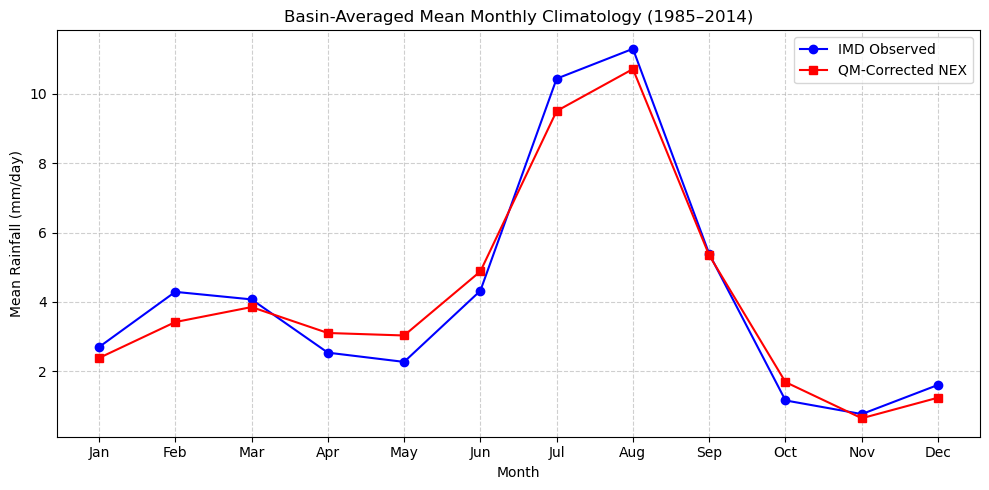

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
# --- Step 5: Plot monthly climatology ---
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))
plt.plot(months_labels, obs_vals, marker='o', color='blue', label='IMD Observed')
plt.plot(months_labels, model_vals, marker='s', color='red', label='QM-Corrected NEX')
plt.xlabel('Month')
plt.ylabel('Mean Rainfall (mm/day)')
plt.title('Basin-Averaged Mean Monthly Climatology (1985–2014)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

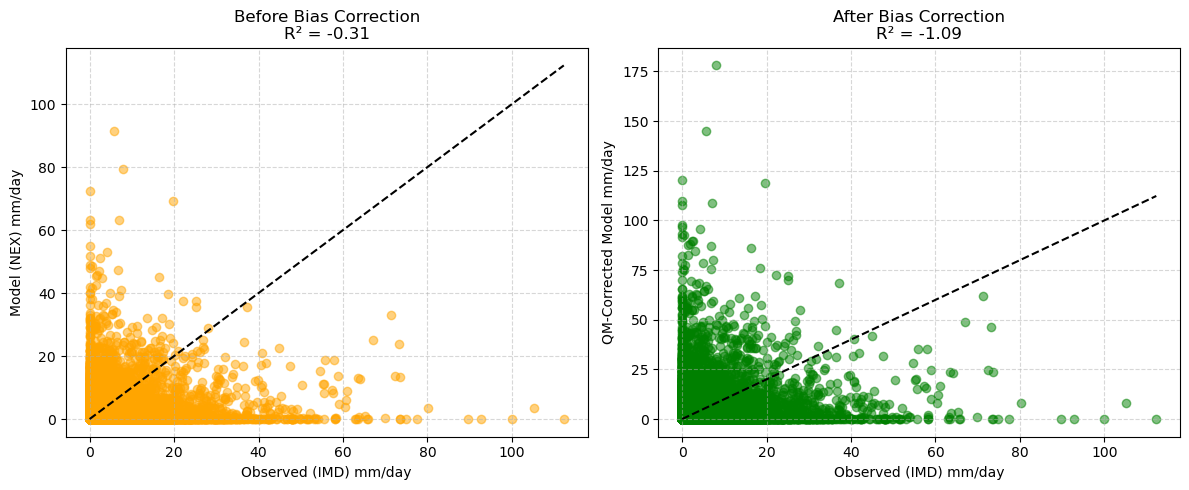

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

# --- Step 1: Flatten spatial-temporal arrays for scatter plot ---
# Before bias correction
model_flat = np.nanmean(nex_clip.values, axis=(1,2))  # basin-averaged daily values
obs_flat   = np.nanmean(imd_clip.values, axis=(1,2))

# After bias correction
model_qm_flat = np.nanmean(nex_corrected.values, axis=(1,2))

# --- Step 2: Compute R² ---
r2_before = r2_score(obs_flat, model_flat)
r2_after  = r2_score(obs_flat, model_qm_flat)

# --- Step 3: Plot scatter plots ---
plt.figure(figsize=(12,5))

# Before bias correction
plt.subplot(1,2,1)
plt.scatter(obs_flat, model_flat, color='orange', alpha=0.5)
plt.plot([obs_flat.min(), obs_flat.max()], [obs_flat.min(), obs_flat.max()], 'k--')
plt.xlabel('Observed (IMD) mm/day')
plt.ylabel('Model (EC-EARTH3) mm/day')
plt.title(f'Before Bias Correction\nR² = {r2_before:.2f}')
plt.grid(True, linestyle='--', alpha=0.5)

# After bias correction
plt.subplot(1,2,2)
plt.scatter(obs_flat, model_qm_flat, color='green', alpha=0.5)
plt.plot([obs_flat.min(), obs_flat.max()], [obs_flat.min(), obs_flat.max()], 'k--')
plt.xlabel('Observed (IMD) mm/day')
plt.ylabel('EC-EARTH3 mm/day')
plt.title(f'After Bias Correction\nR² = {r2_after:.2f}')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


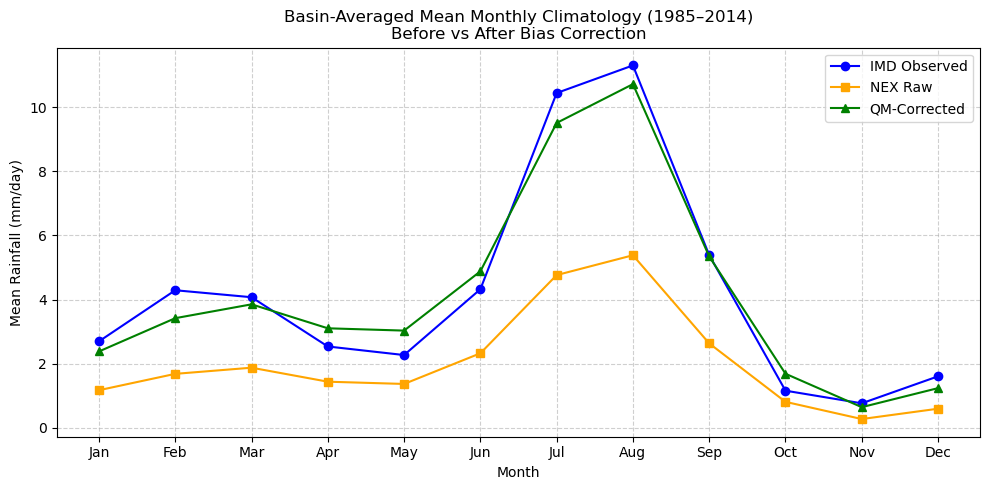

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Daily basin-averaged values ---
obs_daily = np.nanmean(imd_clip.values, axis=(1,2))
model_raw = np.nanmean(nex_clip.values, axis=(1,2))
model_qm  = np.nanmean(nex_corrected.values, axis=(1,2))

# --- Step 2: Time index ---
dates = pd.to_datetime(imd_clip.time.values)
months = pd.Series(dates.month, index=dates)

# --- Step 3: Compute mean monthly climatology ---
obs_monthly = [obs_daily[months==m].mean() for m in range(1,13)]
model_monthly = [model_raw[months==m].mean() for m in range(1,13)]
model_qm_monthly = [model_qm[months==m].mean() for m in range(1,13)]

# --- Step 4: Plot ---
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))
plt.plot(months_labels, obs_monthly, marker='o', color='blue', label='IMD Observed')
plt.plot(months_labels, model_monthly, marker='s', color='orange', label='NEX Raw')
plt.plot(months_labels, model_qm_monthly, marker='^', color='green', label='QM-Corrected')
plt.xlabel('Month')
plt.ylabel('Mean Rainfall (mm/day)')
plt.title('Basin-Averaged Mean Monthly Climatology (1985–2014)\nBefore vs After Bias Correction')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


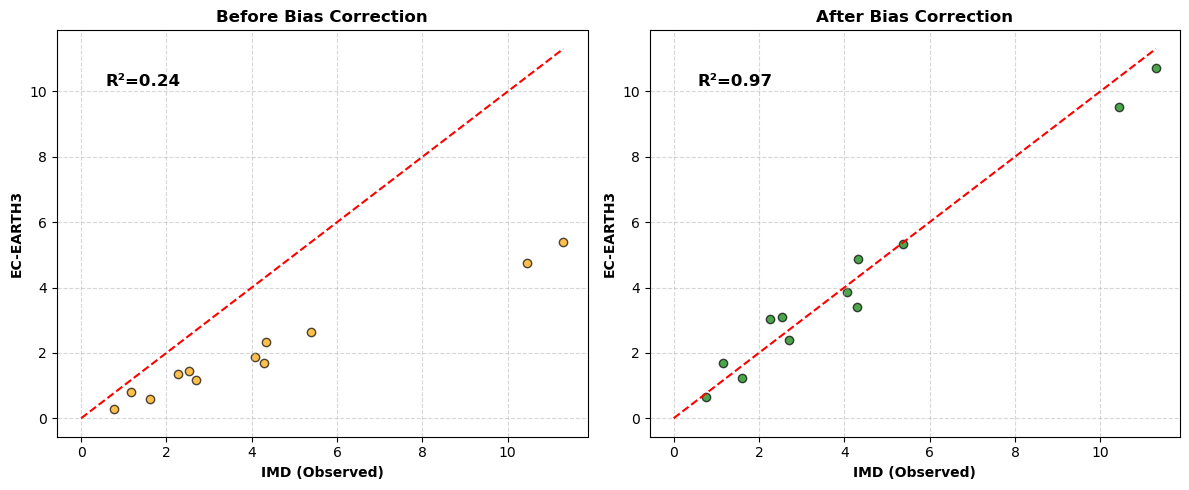

In [27]:
# Step 5: Scatter Plots (Monthly Climatology)
from sklearn.metrics import r2_score
# -------------------------
plt.figure(figsize=(12,5))

# Before Bias Correction
plt.subplot(1,2,1)
plt.scatter(obs_monthly,model_monthly, color='orange', alpha=0.7, edgecolor='k')
plt.plot([0, max(obs_monthly)], [0, max(obs_monthly)], 'r--', linewidth=1.5)
r2_before = r2_score(obs_monthly, model_monthly)
plt.text(0.05*max(obs_monthly), 0.9*max(obs_monthly), f'R²={r2_before:.2f}', fontsize=12,fontweight='bold')
plt.xlabel("IMD (Observed)",fontweight='bold')
plt.ylabel("EC-EARTH3",fontweight='bold')
plt.title("Before Bias Correction",fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# After Bias Correction
plt.subplot(1,2,2)
plt.scatter(obs_monthly, model_qm_monthly, color='green', alpha=0.7, edgecolor='k')
plt.plot([0, max(obs_monthly)], [0, max(obs_monthly)], 'r--', linewidth=1.5)
r2_after = r2_score(obs_monthly, model_qm_monthly)
plt.text(0.05*max(obs_monthly), 0.9*max(obs_monthly), f'R²={r2_after:.2f}', fontsize=12,fontweight='bold')
plt.xlabel("IMD (Observed)",fontweight='bold')
plt.ylabel("EC-EARTH3",fontweight='bold')
plt.title("After Bias Correction",fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/scatter_monthly_climatology.png", dpi=900, bbox_inches='tight')

plt.tight_layout()
plt.show()




In [22]:
import pandas as pd
import numpy as np

# --- Step 1: Compute basin-averaged daily series ---
obs_daily_mean = np.nanmean(imd_clip.values, axis=(1,2))
model_daily_mean = np.nanmean(nex_clip.values, axis=(1,2))
model_qm_daily_mean = np.nanmean(nex_corrected.values, axis=(1,2))

# --- Step 2: Prepare DataFrame ---
dates = pd.to_datetime(imd_clip.time.values)

df_daily = pd.DataFrame({
    'Date': dates,
    'IMD_obs': obs_daily_mean,
    'NEX_raw': model_daily_mean,
    'NEX_QM_corrected': model_qm_daily_mean
})

# --- Step 3: Save to CSV ---
output_csv = "C:/Climate data/GFDL-CM4_basin_daily_avg.csv"
df_daily.to_csv(output_csv, index=False)
print(f"✅ Daily basin-averaged data saved to: {output_csv}")


✅ Daily basin-averaged data saved to: C:/Climate data/GFDL-CM4_basin_daily_avg.csv


In [144]:
# Show the first 10 rows
print(df_daily.head(10))

        Date    IMD_obs   NEX_raw  NEX_QM_corrected
0 1985-01-01  18.185249  0.000000          0.000000
1 1985-01-02   1.845923  0.000000          0.000000
2 1985-01-03   0.988045  0.000000          0.000000
3 1985-01-04   1.765032  0.055558          0.756781
4 1985-01-05  20.157715  0.833390          3.919431
5 1985-01-06  13.656614  0.000000          0.000000
6 1985-01-07   0.289626  0.000000          0.000000
7 1985-01-08   9.117579  0.000000          0.000000
8 1985-01-09   0.660079  0.000000          0.000000
9 1985-01-10   0.000000  0.000000          0.000000


## Scatte plot for each month

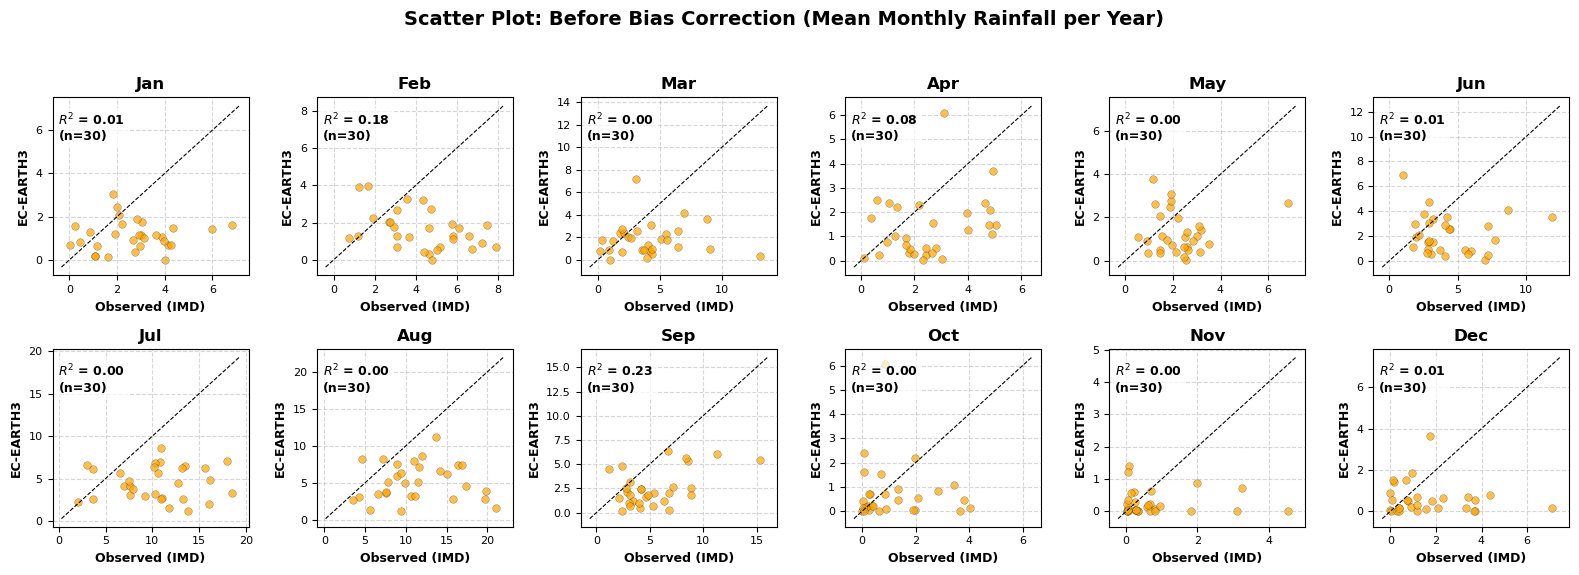

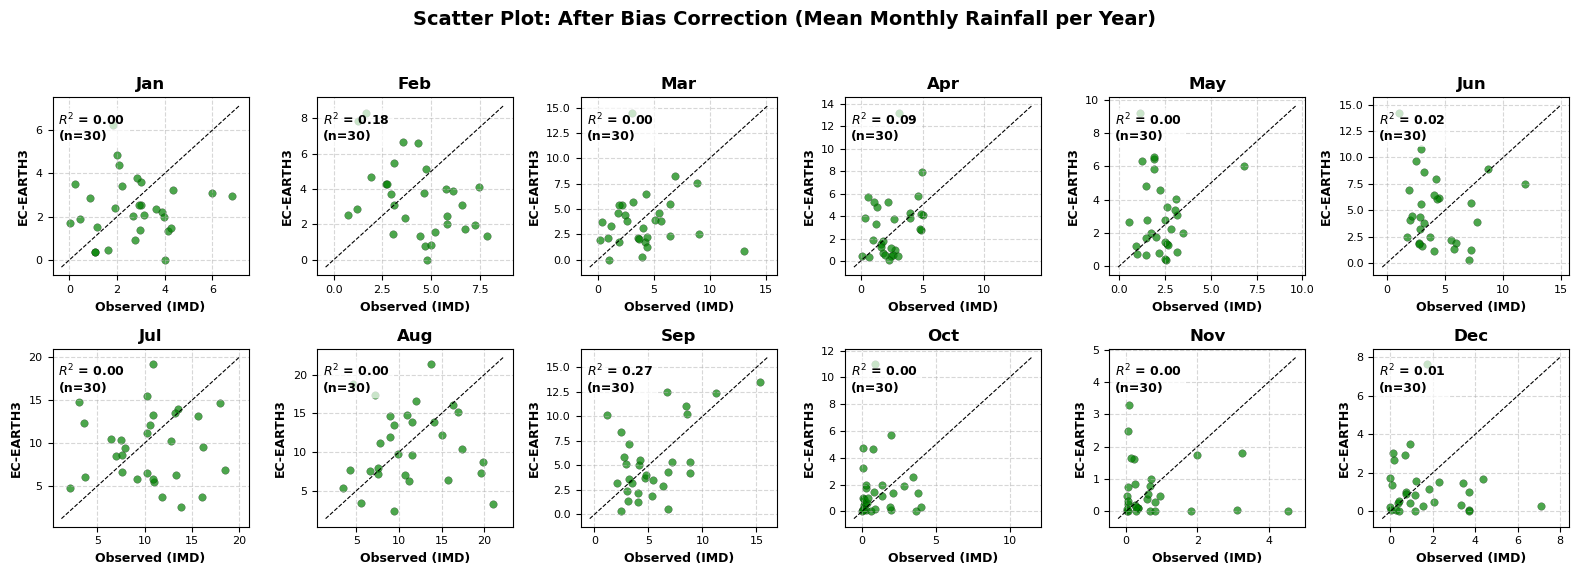

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from scipy.stats import linregress

# --- Step 1: Prepare daily basin-averaged series (assume arrays exist) ---
# obs_daily = np.nanmean(imd_clip.values, axis=(1,2))
# model_daily = np.nanmean(nex_regridded.values, axis=(1,2))
# model_qm_daily = np.nanmean(nex_corrected.values, axis=(1,2))
# dates = pd.to_datetime(imd_clip.time.values)

# --- Step 2: Create DataFrame ---
df = pd.DataFrame({
    'Date': dates,
    'Year': dates.year,
    'Month': dates.month,
    'IMD_obs': obs_daily,
    'NEX_raw': model_daily,
    'NEX_QM': model_qm_daily
})

# --- Step 3: Compute mean monthly rainfall for each year ---
monthly_means = df.groupby(['Year','Month']).mean().reset_index()

# --- Month names ---
month_names = calendar.month_abbr  # ['', 'Jan', 'Feb', ..., 'Dec']

# --- Helper: 1:1 line limits ---
def one_to_one_limits(x, y, pad=0.05):
    # remove NaNs before min/max
    x_ = np.array(x)[~np.isnan(x)]
    y_ = np.array(y)[~np.isnan(y)]
    if x_.size == 0 or y_.size == 0:
        return 0, 1
    mn = min(np.nanmin(x_), np.nanmin(y_))
    mx = max(np.nanmax(x_), np.nanmax(y_))
    if np.isclose(mn, mx):
        mn -= 0.5
        mx += 0.5
    rng = mx - mn
    return mn - pad*rng, mx + pad*rng

# --- Function to compute R^2 safely ---
def compute_r2(x, y):
    # remove NaNs and require at least 2 points
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.sum(mask)
    x_, y_ = x[mask], y[mask]
    lr = linregress(x_, y_)
    r2 = lr.rvalue**2
    return r2, np.sum(mask)

# ======================================================
#     BEFORE BIAS CORRECTION
# ======================================================
plt.figure(figsize=(16,6))

for i, m in enumerate(range(1, 13), start=1):
    df_month = monthly_means[monthly_means['Month'] == m]
    ax = plt.subplot(2, 6, i)

    x = df_month['IMD_obs'].values
    y = df_month['NEX_raw'].values

    # scatter
    ax.scatter(x, y, color='orange', alpha=0.7, edgecolor='k', linewidth=0.2, s=30)

    # 1:1 line
    lo, hi = one_to_one_limits(x, y)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)

    # compute R^2 and n
    r2, npts = compute_r2(x, y)
    if np.isfinite(r2):
        txt = f"$R^2$ = {r2:.2f}\n(n={int(npts)})"
    else:
        txt = "R²: n<2"

    # annotate inside the axes (use axes coords)
    ax.text(
        0.03, 0.92, txt,
        transform=ax.transAxes,
        fontsize=9,
        fontweight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')
    )

    ax.set_title(month_names[m], fontsize=12, fontweight='bold')
    ax.set_xlabel("Observed (IMD)", fontsize=9, fontweight='bold')
    ax.set_ylabel("EC-EARTH3", fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=8)

plt.suptitle("Scatter Plot: Before Bias Correction (Mean Monthly Rainfall per Year)",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/scatter_monthly_raw.png",
            dpi=900, bbox_inches='tight')
plt.show()


# ======================================================
#     AFTER BIAS CORRECTION
# ======================================================
plt.figure(figsize=(16,6))

for i, m in enumerate(range(1, 13), start=1):
    df_month = monthly_means[monthly_means['Month'] == m]
    ax = plt.subplot(2, 6, i)

    x = df_month['IMD_obs'].values
    y = df_month['NEX_QM'].values

    ax.scatter(x, y, color='green', alpha=0.7, edgecolor='k', linewidth=0.2, s=30)

    lo, hi = one_to_one_limits(x, y)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)

    r2, npts = compute_r2(x, y)
    if np.isfinite(r2):
        txt = f"$R^2$ = {r2:.2f}\n(n={int(npts)})"
    else:
        txt = "R²: n<2"

    ax.text(
        0.03, 0.92, txt,
        transform=ax.transAxes,
        fontsize=9,
        fontweight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')
    )

    ax.set_title(month_names[m], fontsize=12, fontweight='bold')
    ax.set_xlabel("Observed (IMD)", fontsize=9, fontweight='bold')
    ax.set_ylabel("EC-EARTH3", fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=8)

plt.suptitle("Scatter Plot: After Bias Correction (Mean Monthly Rainfall per Year)",
             fontsize=14, fontweight='bold')
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/afterbiasscatter_monthly_raw.png",
            dpi=900, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [37]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import calendar

# monthly_means is your DataFrame (Year, Month, IMD_obs, NEX_raw, NEX_QM)
# If not already defined, create it exactly like in your script.

def per_month_diagnostics(monthly_means, obs_col='IMD_obs', model_col='NEX_QM'):
    print("Month | n | Pearson r | R^2 | slope | intercept | obs mean/std | mod mean/std | obs_min,mod_min, obs_max,mod_max")
    for m in range(1,13):
        dfm = monthly_means[monthly_means['Month']==m]
        x = dfm[obs_col].values
        y = dfm[model_col].values
        mask = np.isfinite(x) & np.isfinite(y)
        n = np.sum(mask)
        if n < 2:
            print(f"{calendar.month_abbr[m]:>3} | {n:2d} | not enough data")
            continue
        x_ = x[mask].astype(float)
        y_ = y[mask].astype(float)

        # variance check
        obs_std = np.nanstd(x_)
        mod_std = np.nanstd(y_)

        # linear regression
        lr = linregress(x_, y_)
        r = lr.rvalue
        r2 = r**2
        slope = lr.slope
        intercept = lr.intercept

        print(f"{calendar.month_abbr[m]:>3} | {n:2d} | {r: .4f} | {r2: .4f} | {slope: .3f} | {intercept: .3f} | "
              f"{x_.mean():.3f}/{obs_std:.3f} | {y_.mean():.3f}/{mod_std:.3f} | "
              f"{x_.min():.3f},{y_.min():.3f},{x_.max():.3f},{y_.max():.3f}")

# Run diagnostics for QM-corrected (change to NEX_raw to check pre-correction)
per_month_diagnostics(monthly_means, obs_col='IMD_obs', model_col='NEX_QM')


Month | n | Pearson r | R^2 | slope | intercept | obs mean/std | mod mean/std | obs_min,mod_min, obs_max,mod_max
Jan | 30 |  0.0310 |  0.0010 |  0.027 |  2.308 | 2.696/1.569 | 2.381/1.378 | 0.025,0.009,6.802,6.253
Feb | 30 | -0.4251 |  0.1807 | -0.454 |  5.362 | 4.291/1.925 | 3.412/2.058 | 0.757,0.000,7.889,8.315
Mar | 30 |  0.0370 |  0.0014 |  0.037 |  3.699 | 4.073/2.807 | 3.851/2.818 | 0.162,0.000,13.083,14.494
Apr | 30 |  0.2941 |  0.0865 |  0.550 |  1.709 | 2.536/1.479 | 3.103/2.764 | 0.110,0.116,5.044,13.199
May | 30 |  0.0467 |  0.0022 |  0.092 |  2.822 | 2.269/1.128 | 3.032/2.236 | 0.526,0.384,6.835,9.223
Jun | 30 | -0.1237 |  0.0153 | -0.170 |  5.615 | 4.322/2.405 | 4.881/3.303 | 1.005,0.302,11.916,14.227
Jul | 30 |  0.0149 |  0.0002 |  0.014 |  9.359 | 10.442/4.219 | 9.508/4.062 | 2.075,2.541,18.478,19.163
Aug | 30 |  0.0316 |  0.0010 |  0.032 |  10.356 | 11.303/4.717 | 10.719/4.798 | 3.479,2.340,21.020,21.340
Sep | 30 |  0.5203 |  0.2707 |  0.624 |  1.982 | 5.386/3.046 | 5.3

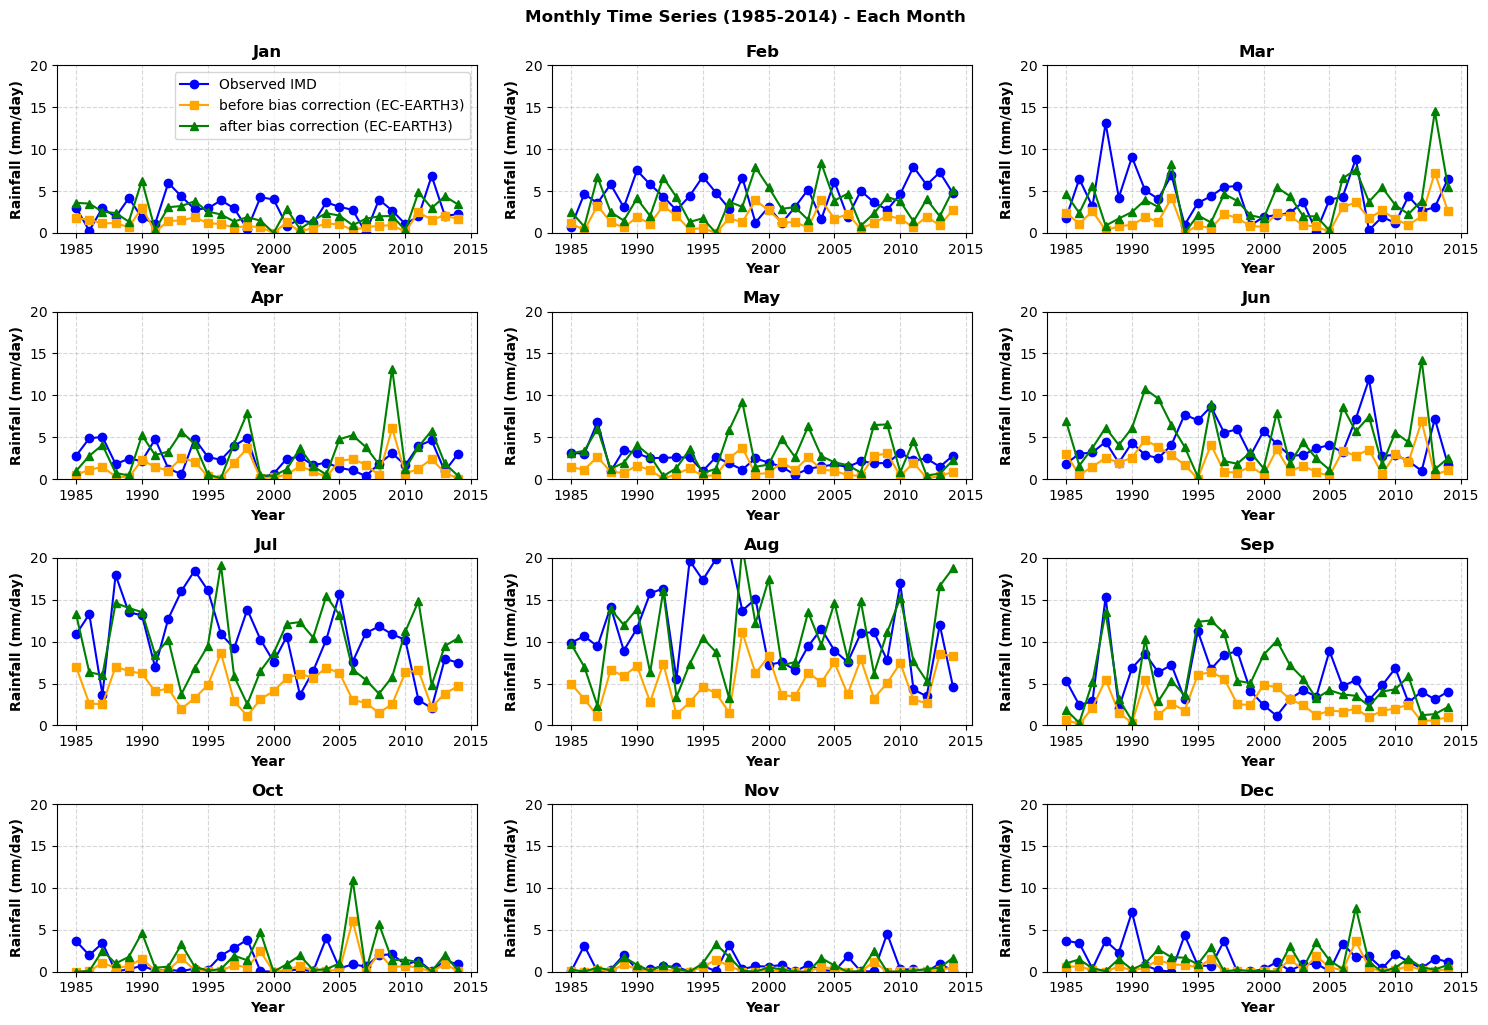

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Daily basin-averaged series ---
obs_daily = np.nanmean(imd_clip.values, axis=(1,2))
model_raw_daily = np.nanmean(nex_regridded.values, axis=(1,2))
model_qm_daily = np.nanmean(nex_corrected.values, axis=(1,2))

dates = pd.to_datetime(imd_clip.time.values)

# --- Step 2: Create DataFrame ---
df = pd.DataFrame({
    'Date': dates,
    'Year': dates.year,
    'Month': dates.month,
    'IMD_obs': obs_daily,
    'NEX_raw': model_raw_daily,
    'NEX_QM': model_qm_daily
})

# --- Step 3: Compute monthly mean for each year ---
monthly_ts = df.groupby(['Year','Month']).mean().reset_index()
month_names = calendar.month_abbr  # ['', 'Jan', 'Feb', ..., 'Dec']
# --- Choose y-axis upper limit ---
Y_MAX = 20 

# --- Step 4: Plot monthly time series for each month across years ---
months = range(1, 13)
plt.figure(figsize=(15, 10))

for m in months:
    df_month = monthly_ts[monthly_ts['Month'] == m]
    
    plt.subplot(4, 3, m)
    plt.plot(df_month['Year'], df_month['IMD_obs'], marker='o', label='Observed IMD', color='blue')
    plt.plot(df_month['Year'], df_month['NEX_raw'], marker='s', label='before bias correction (EC-EARTH3)', color='orange')
    plt.plot(df_month['Year'], df_month['NEX_QM'], marker='^', label='after bias correction (EC-EARTH3)', color='green')
    
    plt.title(month_names[m], fontsize=12, fontweight='bold')
    plt.xlabel('Year',fontweight='bold')
    plt.ylabel('Rainfall (mm/day)',fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
 # --- Scale the Y-axis for all plots ---
    plt.ylim(0, Y_MAX)
    if m == 1:
        plt.legend(loc='upper right')

plt.tight_layout()
plt.suptitle("Monthly Time Series (1985-2014) - Each Month",fontweight='bold', y=1.02)
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/timeseries_monthly.png", dpi=900, bbox_inches='tight')
plt.show()


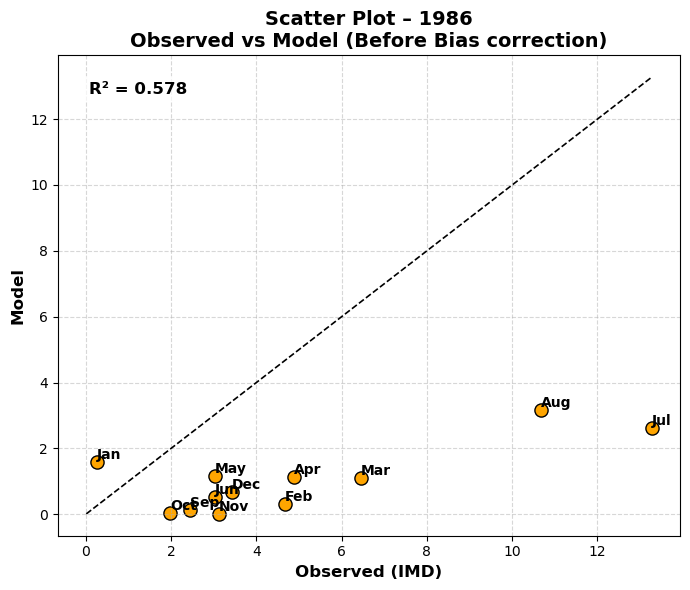

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import calendar

# -------------------------------
# Prepare monthly means (you already have df)
# -------------------------------

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly = df.groupby(['Year','Month'])[['IMD_obs','Before Bias correction','After Bias correction']].mean().reset_index()

# -------------------------------
# Select YEAR and model type
# -------------------------------

YEAR = 1986
MODEL_COL = "Before Bias correction"       # ← change to "NEX_QM" if you want QM corrected

dfy = monthly[monthly['Year'] == YEAR].sort_values('Month')

x = dfy['IMD_obs'].values
y = dfy[MODEL_COL].values

# -------------------------------
# Compute R²
# -------------------------------

mask = np.isfinite(x) & np.isfinite(y)
r2 = np.corrcoef(x[mask], y[mask])[0,1]**2

# -------------------------------
# Scatter plot
# -------------------------------

plt.figure(figsize=(7,6))

plt.scatter(x, y, s=90, color='orange', edgecolor='k')

# 1:1 line
mn = min(np.min(x), np.min(y))
mx = max(np.max(x), np.max(y))
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1.2)

# label points with month names
for xi, yi, m in zip(x, y, dfy['Month']):
    plt.text(xi, yi, calendar.month_abbr[m], fontsize=10, fontweight='bold',
             ha='left', va='bottom')

plt.title(f"Scatter Plot – {YEAR}\nObserved vs Model ({MODEL_COL})", fontsize=14, fontweight="bold")
plt.xlabel("Observed (IMD)", fontsize=12, fontweight="bold")
plt.ylabel("Model", fontsize=12, fontweight="bold")

plt.grid(True, linestyle='--', alpha=0.5)

# Add R² box
plt.text(0.05, 0.92, f"R² = {r2:.3f}",
         transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()


In [53]:
print(df.columns.tolist())


['Date', 'IMD_obs', 'Before Bias correction', 'After Bias correction', 'Year', 'Month']


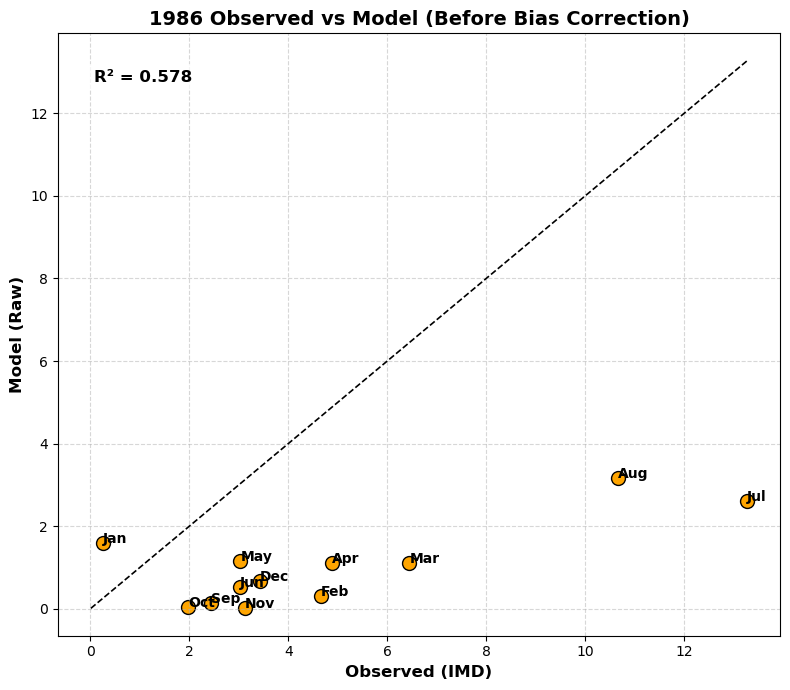

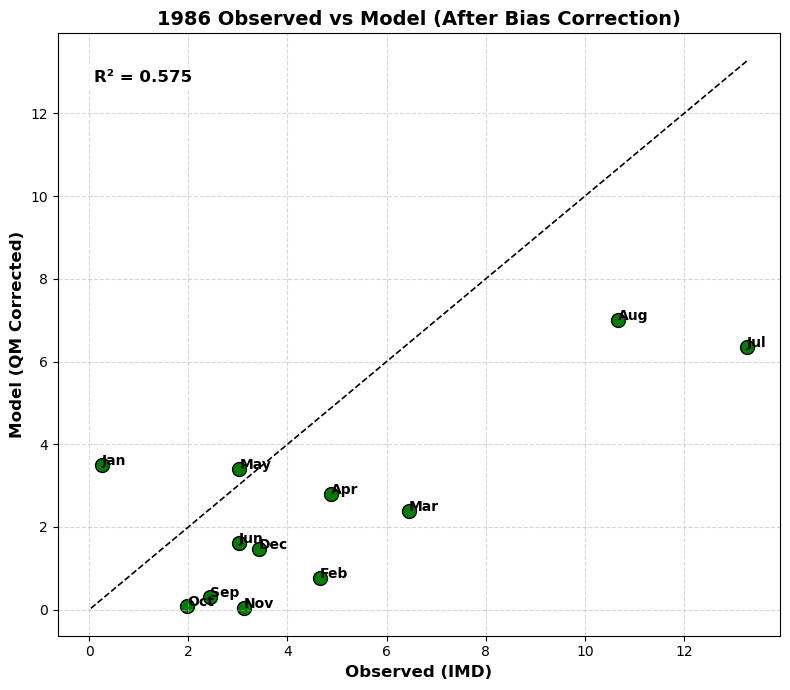

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import calendar

# -------------------------------
# Prepare monthly means
# -------------------------------
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly = df.groupby(['Year','Month'])[['IMD_obs','Before Bias correction','After Bias correction']].mean().reset_index()

# -------------------------------
# Select YEAR
# -------------------------------
YEAR = 1986

dfy = monthly[monthly['Year'] == YEAR].sort_values('Month')

x = dfy['IMD_obs'].values
y_raw = dfy['Before Bias correction'].values
y_qm  = dfy['After Bias correction'].values

# -------------------------------
# R² function
# -------------------------------
def safe_r2(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    return (np.corrcoef(a[mask], b[mask])[0,1] ** 2)

r2_raw = safe_r2(x, y_raw)
r2_qm  = safe_r2(x, y_qm)

# -------------------------------
# 1st Plot — BEFORE Bias Correction
# -------------------------------
plt.figure(figsize=(8,7))
plt.scatter(x, y_raw, s=100, color='orange', edgecolor='k')

# 1:1 line
mn = min(np.min(x), np.min(y_raw))
mx = max(np.max(x), np.max(y_raw))
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1.2)

# Month labels
for xi, yi, m in zip(x, y_raw, dfy['Month']):
    plt.text(xi, yi, calendar.month_abbr[m], fontsize=10, fontweight='bold')

plt.title(f"1986 Observed vs Model (Before Bias Correction)", fontsize=14, fontweight='bold')
plt.xlabel("Observed (IMD)", fontsize=12, fontweight='bold')
plt.ylabel("Model (Raw)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.text(0.05, 0.92, f"R² = {r2_raw:.3f}", transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

plt.tight_layout()
plt.show()

# -------------------------------
# 2nd Plot — AFTER Bias Correction
# -------------------------------
plt.figure(figsize=(8,7))
plt.scatter(x, y_qm, s=100, color='green', edgecolor='k')

mn = min(np.min(x), np.min(y_qm))
mx = max(np.max(x), np.max(y_qm))
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1.2)

# Month labels
for xi, yi, m in zip(x, y_qm, dfy['Month']):
    plt.text(xi, yi, calendar.month_abbr[m], fontsize=10, fontweight='bold')

plt.title(f"1986 Observed vs Model (After Bias Correction)", fontsize=14, fontweight='bold')
plt.xlabel("Observed (IMD)", fontsize=12, fontweight='bold')
plt.ylabel("Model (QM Corrected)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.text(0.05, 0.92, f"R² = {r2_qm:.3f}", transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

plt.tight_layout()
plt.show()


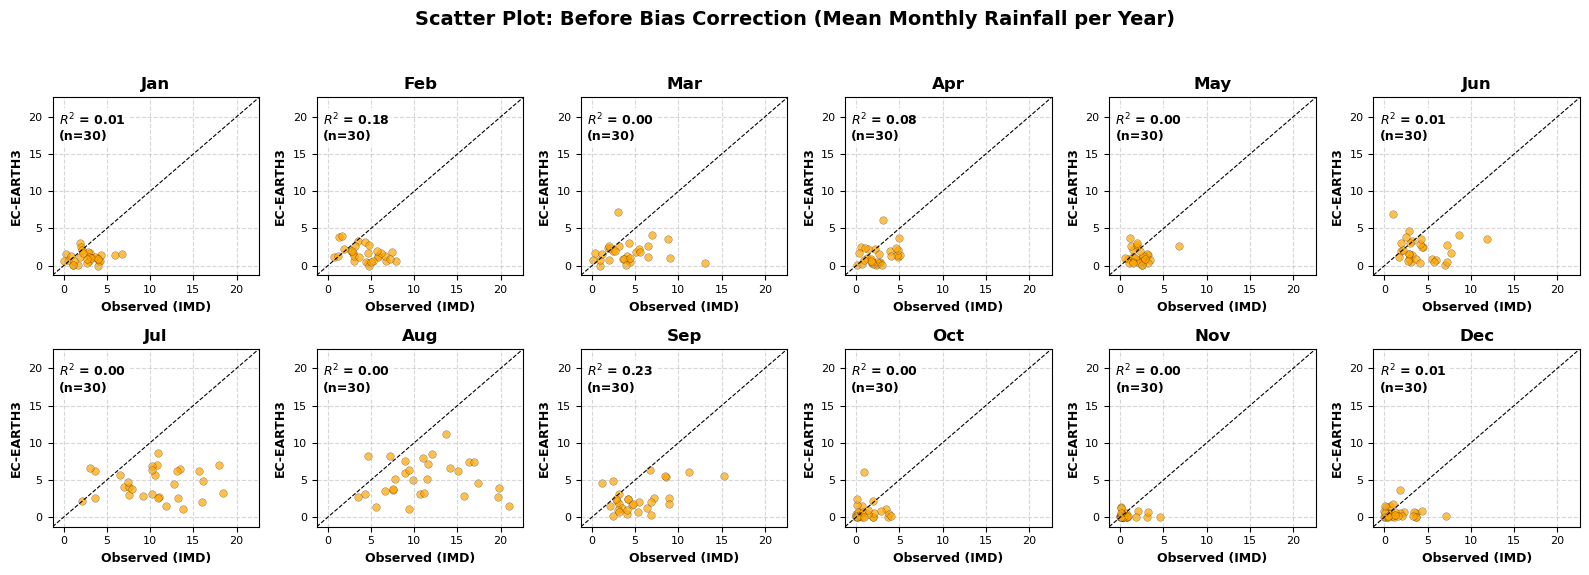

Saved: C:/Users/Windows/Desktop/Climate Figures/scatter_monthly_raw.png


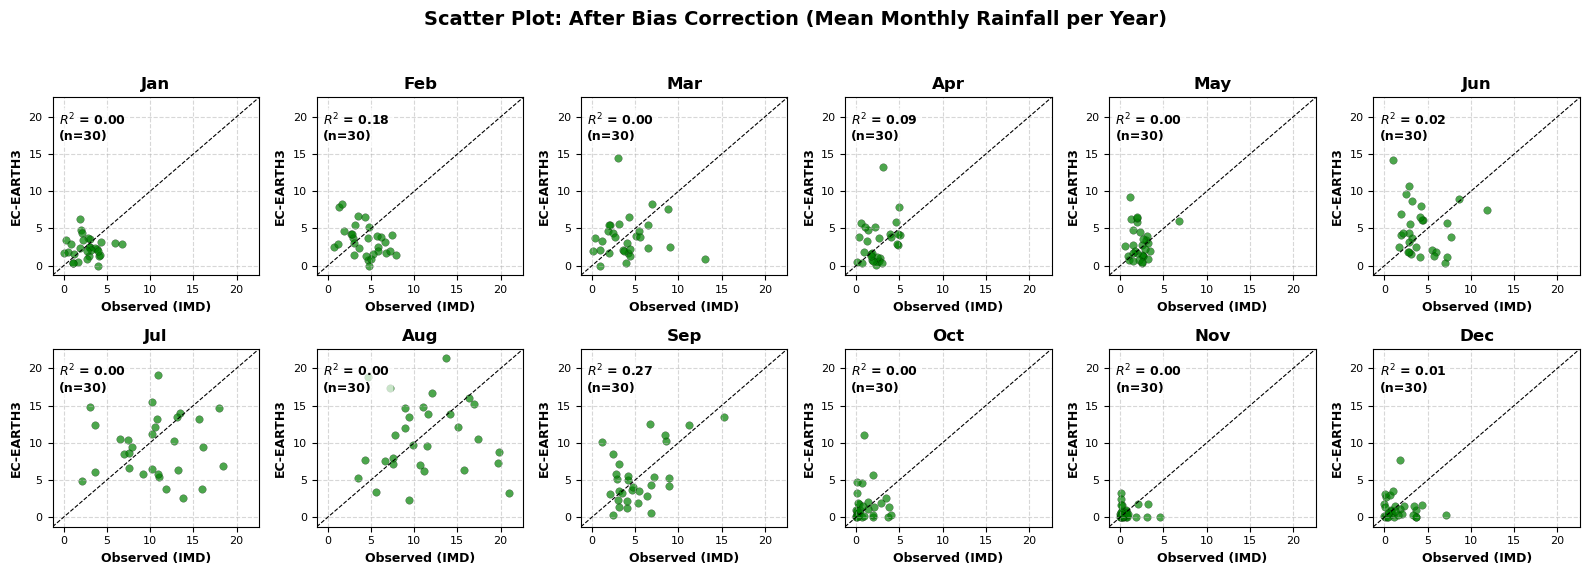

Saved: C:/Users/Windows/Desktop/Climate Figures/scatter_monthly_qm.png


In [63]:
# --- compute global limits across all months & both raw+qm so both figures match ---
all_obs = monthly_means['IMD_obs'].values
all_raw = monthly_means['NEX_raw'].values
all_qm  = monthly_means['NEX_QM'].values

# re-use your helper but applied to combined arrays
def global_one_to_one_limits(arr1, arr2, pad=0.05):
    a = np.array(arr1)[np.isfinite(arr1)]
    b = np.array(arr2)[np.isfinite(arr2)]
    if a.size == 0 or b.size == 0:
        return 0, 1
    mn = min(a.min(), b.min())
    mx = max(a.max(), b.max())
    if np.isclose(mn, mx):
        mn -= 0.5; mx += 0.5
    rng = mx - mn
    return mn - pad*rng, mx + pad*rng

# compute global lo/hi using the union of obs and models
lo, hi = global_one_to_one_limits(
    np.concatenate([all_obs, all_raw, all_qm]),
    np.concatenate([all_obs, all_raw, all_qm]),
    pad=0.06
)

# common save parameters
OUTDIR = "C:/Users/Windows/Desktop/Climate Figures"
dpi = 900
pad = 0.04   # pad_inches for bbox

# -------------------------
# BEFORE BIAS CORRECTION (RAW)
# -------------------------
fig = plt.figure(figsize=(16,6))
for i, m in enumerate(range(1, 13), start=1):
    df_month = monthly_means[monthly_means['Month'] == m]
    ax = plt.subplot(2, 6, i)

    x = df_month['IMD_obs'].values
    y = df_month['NEX_raw'].values

    ax.scatter(x, y, color='orange', alpha=0.7, edgecolor='k', linewidth=0.2, s=30)
    # use GLOBAL 1:1 line and limits
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)

    r2, npts = compute_r2(x, y)
    txt = f"$R^2$ = {r2:.2f}\n(n={int(npts)})" if np.isfinite(r2) else "R²: n<2"

    ax.text(0.03, 0.92, txt, transform=ax.transAxes,
            fontsize=9, fontweight='bold', verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.set_title(month_names[m], fontsize=12, fontweight='bold')
    ax.set_xlabel("Observed (IMD)", fontsize=9, fontweight='bold')
    ax.set_ylabel("EC-EARTH3", fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.tick_params(labelsize=8)
    ax.set_aspect('auto')

plt.suptitle("Scatter Plot: Before Bias Correction (Mean Monthly Rainfall per Year)",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# SAVE before showing
out1 = f"{OUTDIR}/scatter_monthly_raw.png"
fig.savefig(out1, dpi=dpi, bbox_inches='tight', pad_inches=pad)
plt.show()
plt.show(fig)
print("Saved:", out1)

# -------------------------
# AFTER BIAS CORRECTION (QM)
# -------------------------
fig = plt.figure(figsize=(16,6))
for i, m in enumerate(range(1, 13), start=1):
    df_month = monthly_means[monthly_means['Month'] == m]
    ax = plt.subplot(2, 6, i)

    x = df_month['IMD_obs'].values
    y = df_month['NEX_QM'].values

    ax.scatter(x, y, color='green', alpha=0.7, edgecolor='k', linewidth=0.2, s=30)
    # global 1:1 line + limits same as raw figure
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)

    r2, npts = compute_r2(x, y)
    txt = f"$R^2$ = {r2:.2f}\n(n={int(npts)})" if np.isfinite(r2) else "R²: n<2"

    ax.text(0.03, 0.92, txt, transform=ax.transAxes,
            fontsize=9, fontweight='bold', verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.set_title(month_names[m], fontsize=12, fontweight='bold')
    ax.set_xlabel("Observed (IMD)", fontsize=9, fontweight='bold')
    ax.set_ylabel("EC-EARTH3", fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.tick_params(labelsize=8)
    ax.set_aspect('auto')

plt.suptitle("Scatter Plot: After Bias Correction (Mean Monthly Rainfall per Year)",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# SAVE before showing (same dpi and bbox options)
out2 = f"{OUTDIR}/scatter_monthly_qm.png"
fig.savefig(out2, dpi=dpi, bbox_inches='tight', pad_inches=pad)
plt.show()
plt.show(fig)
print("Saved:", out2)


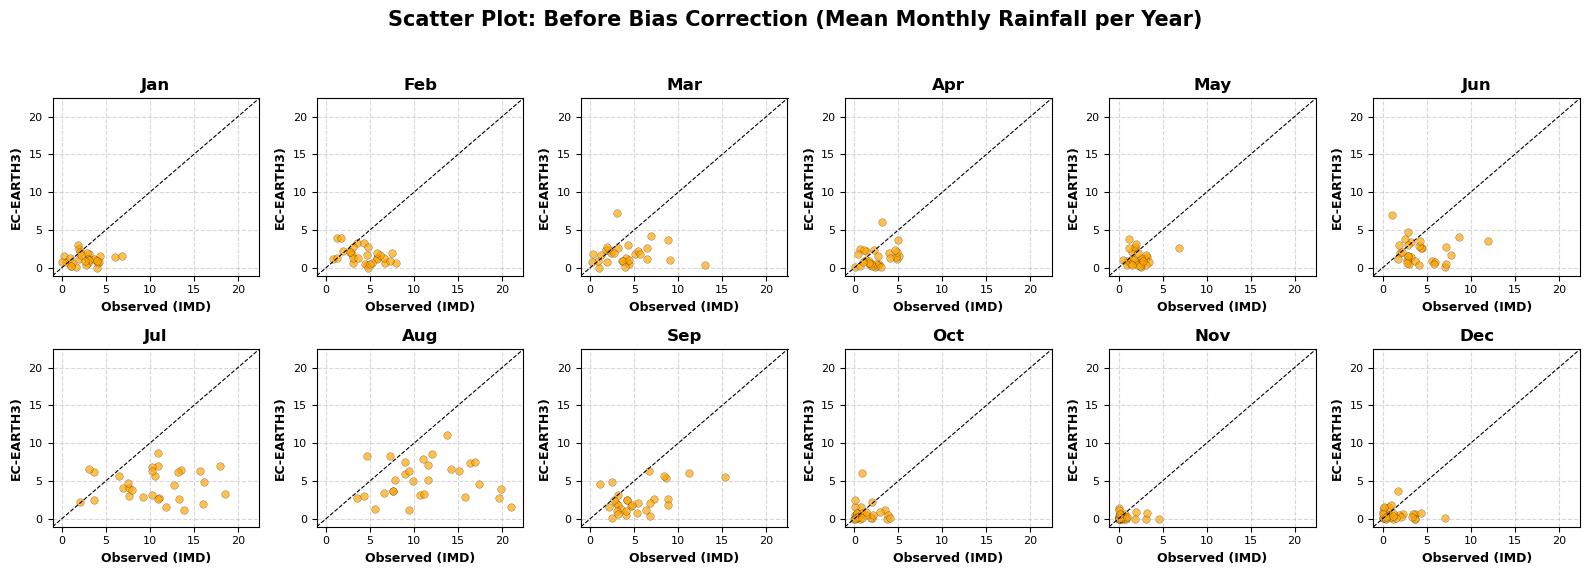

Saved: C:/Users/Windows/Desktop/Climate Figures/scatter_monthly_withoutr2.png.png


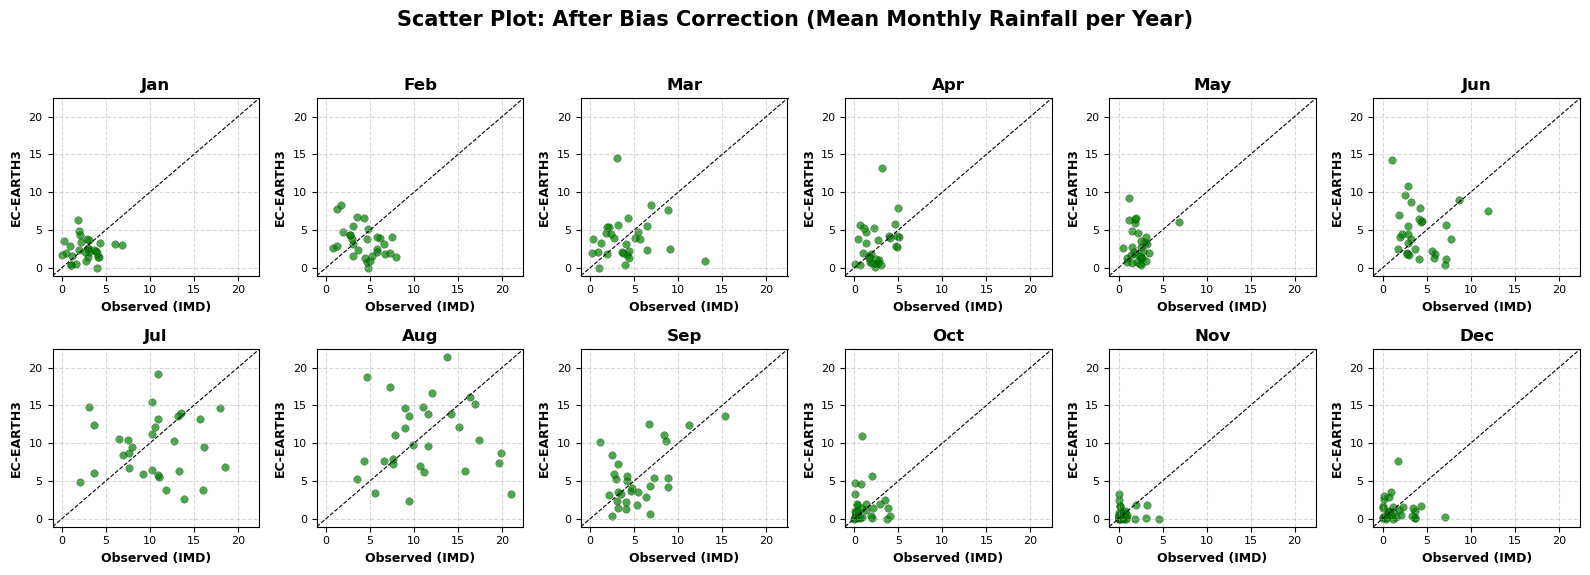

Saved: C:/Users/Windows/Desktop/Climate Figures/scatter_monthly_withoutr2.png.png


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from scipy.stats import linregress

# ------------------------------------------------------
# Create DataFrame (your existing variables remain same)
# ------------------------------------------------------
df = pd.DataFrame({
    'Date': dates,
    'Year': dates.year,
    'Month': dates.month,
    'IMD_obs': obs_daily,
    'NEX_raw': model_daily,
    'NEX_QM': model_qm_daily
})

# ------------------------------------------------------
# Monthly means
# ------------------------------------------------------
monthly_means = df.groupby(['Year','Month']).mean().reset_index()
month_names = calendar.month_abbr  # ['', 'Jan','Feb',...]

# ------------------------------------------------------
# Compute GLOBAL axis limits so both figures look identical
# ------------------------------------------------------
all_vals = np.concatenate([
    monthly_means['IMD_obs'].values,
    monthly_means['NEX_raw'].values,
    monthly_means['NEX_QM'].values
])

mn = np.nanmin(all_vals)
mx = np.nanmax(all_vals)
pad = 0.05 * (mx - mn)
lo, hi = mn - pad, mx + pad

# ------------------------------------------------------
# Save directory and settings
# ------------------------------------------------------
OUTDIR = "C:/Users/Windows/Desktop/Climate Figures"
dpi = 900

# ======================================================
#     BEFORE BIAS CORRECTION (RAW)
# ======================================================
fig = plt.figure(figsize=(16,6))

for i, m in enumerate(range(1, 13), start=1):

    df_month = monthly_means[monthly_means['Month'] == m]
    x = df_month['IMD_obs'].values
    y = df_month['NEX_raw'].values

    ax = plt.subplot(2, 6, i)
    ax.scatter(x, y, color='orange', alpha=0.7, s=30, edgecolor='k', linewidth=0.2)

    # Global 1:1 line
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)

    # Styling
    ax.set_title(month_names[m], fontsize=12, fontweight='bold')
    ax.set_xlabel("Observed (IMD)", fontsize=9, fontweight='bold')
    ax.set_ylabel("EC-EARTH3)", fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.tick_params(labelsize=8)

plt.suptitle("Scatter Plot: Before Bias Correction (Mean Monthly Rainfall per Year)",
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(f"{OUTDIR}/scatter_monthly_withoutr2.png", dpi=dpi, bbox_inches='tight', pad_inches=0.05)
plt.show()
plt.close(fig)

print("Saved:", f"{OUTDIR}/scatter_monthly_withoutr2.png.png")

# ======================================================
#     AFTER BIAS CORRECTION (QM)
# ======================================================
fig = plt.figure(figsize=(16,6))

for i, m in enumerate(range(1, 13), start=1):

    df_month = monthly_means[monthly_means['Month'] == m]
    x = df_month['IMD_obs'].values
    y = df_month['NEX_QM'].values

    ax = plt.subplot(2, 6, i)
    ax.scatter(x, y, color='green', alpha=0.7, s=30, edgecolor='k', linewidth=0.2)

    # Global 1:1 line
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)

    ax.set_title(month_names[m], fontsize=12, fontweight='bold')
    ax.set_xlabel("Observed (IMD)", fontsize=9, fontweight='bold')
    ax.set_ylabel("EC-EARTH3", fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.tick_params(labelsize=8)

plt.suptitle("Scatter Plot: After Bias Correction (Mean Monthly Rainfall per Year)",
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(f"{OUTDIR}/scatter_monthly_withoutr2.png.png", dpi=dpi, bbox_inches='tight', pad_inches=0.05)
plt.show()
plt.close(fig)

print("Saved:", f"{OUTDIR}/scatter_monthly_withoutr2.png.png")
